In [1]:
import math
import random
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from shapely import affinity
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.strtree import STRtree

# Global numeric settings

In [2]:
pd.set_option("display.float_format", "{:.12f}".format)

# High precision for Decimal computations
getcontext().prec = 25

# Scale factor used to keep coordinates in integer-ish range for Shapely
scale_factor = Decimal("1e15")

# Build the index of the submission, in the format: "<trees_in_problem>_<tree_index>"
index = [f"{n:03d}_{t}" for n in range(1, 201) for t in range(n)]

# Packing configuration: ALL TUNING KNOBS LIVE HERE

In [3]:
PACKING_CONFIG = {
    # --- Rotation Search (degrees) ---
    "rotation_min_deg": -180,  # min relative rotation to try
    "rotation_max_deg": 180,   # max relative rotation to try
    "rotation_step_deg": 10,   # step size between rotations

    # --- Arc Search (radians) ---
    # We keep tree at same radial distance, but sweep angle around the ray
    "arc_max_rad": 1,       # +/- arc angle range (~23 degrees)
    "arc_step_rad": 0.02,     # step size for arc sweep

    # --- Radial movement towards/away from center ---
    "start_radius": Decimal("20.0"),
    "step_in": Decimal("0.5"),
    "step_out": Decimal("0.01"),

    # --- Global attempts ---
    # How many random rays we try per tree to find a good position
    "attempts_per_tree": 1000,

    # --- Collision behaviour ---
    # If True -> only non-touching intersections are treated as collisions
    # If False -> touching counts as collision as well
    "allow_touching": True,
}



# Tree geometry

In [4]:
class ChristmasTree:
    """
    Represents a single, rotatable Christmas tree of a fixed size.

    Coordinates are stored at a high precision scale (scale_factor).
    Angle is in degrees.
    """

    def __init__(self, center_x="0", center_y="0", angle="0"):
        self.center_x = Decimal(center_x)
        self.center_y = Decimal(center_y)
        self.angle = Decimal(angle)  # degrees

        trunk_w = Decimal("0.15")
        trunk_h = Decimal("0.2")
        base_w = Decimal("0.7")
        mid_w = Decimal("0.4")
        top_w = Decimal("0.25")

        tip_y = Decimal("0.8")
        tier_1_y = Decimal("0.5")
        tier_2_y = Decimal("0.25")
        base_y = Decimal("0.0")
        trunk_bottom_y = -trunk_h

        # Define the tree polygon in local coordinates (scaled by scale_factor)
        initial_polygon = Polygon(
            [
                # Start at Tip
                (Decimal("0.0") * scale_factor, tip_y * scale_factor),
                # Right side - Top Tier
                (top_w / Decimal("2") * scale_factor, tier_1_y * scale_factor),
                (top_w / Decimal("4") * scale_factor, tier_1_y * scale_factor),
                # Right side - Middle Tier
                (mid_w / Decimal("2") * scale_factor, tier_2_y * scale_factor),
                (mid_w / Decimal("4") * scale_factor, tier_2_y * scale_factor),
                # Right side - Bottom Tier
                (base_w / Decimal("2") * scale_factor, base_y * scale_factor),
                # Right Trunk
                (trunk_w / Decimal("2") * scale_factor, base_y * scale_factor),
                (trunk_w / Decimal("2") * scale_factor, trunk_bottom_y * scale_factor),
                # Left Trunk
                (-(trunk_w / Decimal("2")) * scale_factor, trunk_bottom_y * scale_factor),
                (-(trunk_w / Decimal("2")) * scale_factor, base_y * scale_factor),
                # Left side - Bottom Tier
                (-(base_w / Decimal("2")) * scale_factor, base_y * scale_factor),
                # Left side - Middle Tier
                (-(mid_w / Decimal("4")) * scale_factor, tier_2_y * scale_factor),
                (-(mid_w / Decimal("2")) * scale_factor, tier_2_y * scale_factor),
                # Left side - Top Tier
                (-(top_w / Decimal("4")) * scale_factor, tier_1_y * scale_factor),
                (-(top_w / Decimal("2")) * scale_factor, tier_1_y * scale_factor),
            ]
        )

        # Store base (unrotated) polygon for easy re-rotation
        self.base_polygon = initial_polygon

        # Initialize actual polygon with current center and angle
        self.update_polygon()

    def update_polygon(self):
        """Recompute self.polygon given self.center_x, self.center_y, and self.angle."""
        rotated = affinity.rotate(self.base_polygon, float(self.angle), origin=(0, 0))
        self.polygon = affinity.translate(
            rotated,
            xoff=float(self.center_x * scale_factor),
            yoff=float(self.center_y * scale_factor),
        )




# Utility functions

In [5]:

def generate_weighted_angle():
    """
    Generates a random angle in radians with distribution weighted by abs(sin(2*angle)).
    This helps place more trees in corners and makes the packing less round.
    """
    while True:
        angle = random.uniform(0, 2 * math.pi)
        if random.uniform(0, 1) < abs(math.sin(2 * angle)):
            return angle


def build_candidate_polygon(tree: ChristmasTree, center_x: Decimal, center_y: Decimal, angle_deg: float):
    """
    Build a candidate Shapely polygon for a given tree at a hypothetical
    center and angle (degrees).
    """
    rotated = affinity.rotate(tree.base_polygon, angle_deg, origin=(0, 0))
    return affinity.translate(
        rotated,
        xoff=float(center_x * scale_factor),
        yoff=float(center_y * scale_factor),
    )


def collides(candidate_poly, placed_polygons, tree_index, cfg):
    """
    Collision check between candidate_poly and all already-placed polygons.
    Uses STRtree for speed.
    """
    if not placed_polygons:
        return False

    possible_indices = tree_index.query(candidate_poly)
    allow_touching = cfg["allow_touching"]

    for i in possible_indices:
        other = placed_polygons[i]
        if candidate_poly.intersects(other):
            if allow_touching:
                # Only count as collision if there's an actual overlap (not just boundary touch)
                if not candidate_poly.touches(other):
                    return True
            else:
                # Any intersection counts as collision
                return True

    return False


def try_rotations_at_position(tree_to_place, px, py, placed_polygons, tree_index, cfg):
    """
    For a fixed center (px, py), try several small rotations around the tree's current angle.
    Returns (success, candidate_poly, angle_offset_deg).
    """
    rot_min = cfg["rotation_min_deg"]
    rot_max = cfg["rotation_max_deg"]
    rot_step = cfg["rotation_step_deg"]

    base_angle_deg = float(tree_to_place.angle)

    for delta_deg in range(rot_min, rot_max + 1, rot_step):
        angle_deg = base_angle_deg + delta_deg
        candidate_poly = build_candidate_polygon(tree_to_place, px, py, angle_deg)
        if not collides(candidate_poly, placed_polygons, tree_index, cfg):
            return True, candidate_poly, Decimal(delta_deg)

    return False, None, Decimal("0")


def try_arc_search(tree_to_place, base_ray_angle, radius, placed_polygons, tree_index, cfg):
    """
    Keep the same radius, sweep around a small angular arc, and at each candidate
    position try the rotation search again.

    Returns:
        (success, best_px, best_py, best_angle_offset_deg, best_candidate_poly)
    """
    arc_max = cfg["arc_max_rad"]
    arc_step = cfg["arc_step_rad"]

    # Prefer positions close to the original angle, so check 0 offset first
    offsets = [0.0]
    pos = arc_step
    while pos <= arc_max:
        offsets.append(pos)
        offsets.append(-pos)
        pos += arc_step

    for dtheta in offsets:
        angle2 = base_ray_angle + dtheta
        vx2 = Decimal(str(math.cos(angle2)))
        vy2 = Decimal(str(math.sin(angle2)))

        px = radius * vx2
        py = radius * vy2

        ok, candidate_poly, angle_offset = try_rotations_at_position(
            tree_to_place, px, py, placed_polygons, tree_index, cfg
        )
        if ok:
            return True, px, py, angle_offset, candidate_poly

    return False, None, None, Decimal("0"), None




# Placement engine


In [6]:
def initialize_trees(num_trees, existing_trees=None):
    """
    Build a greedy configuration by using the previous n-tree placement and adding
    one more tree to get the (n+1)-tree configuration.

    For each new tree:
      1) Start at a large radius along a weighted random ray.
      2) Move inward until first collision (or center).
      3) On collision:
            a) Try local rotations at that radius.
            b) If that fails, try an arc search (move along arc + rotations).
            c) If that fails, fallback: step outwards along the ray until free.
      4) Keep the best (smallest radius) found across several random attempts.

    Returns:
        placed_trees (list[ChristmasTree]), side_length (Decimal)
    """
    cfg = PACKING_CONFIG

    if num_trees == 0:
        return [], Decimal("0")

    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)

    num_to_add = num_trees - len(placed_trees)
    if num_to_add > 0:
        # Create new trees with random initial angles
        unplaced_trees = [
            ChristmasTree(angle=str(random.uniform(0, 360))) for _ in range(num_to_add)
        ]

        # If starting from scratch, first tree at origin
        if not placed_trees:
            first_tree = unplaced_trees.pop(0)
            first_tree.center_x = Decimal("0")
            first_tree.center_y = Decimal("0")
            first_tree.update_polygon()
            placed_trees.append(first_tree)

        for tree_to_place in unplaced_trees:
            placed_polygons = [p.polygon for p in placed_trees]
            tree_index = STRtree(placed_polygons)

            best_px = None
            best_py = None
            best_angle_offset = Decimal("0")
            best_candidate_poly = None
            min_radius = Decimal("Infinity")

            for _ in range(cfg["attempts_per_tree"]):
                # Choose a random direction (ray) from center
                ray_angle = generate_weighted_angle()
                vx = Decimal(str(math.cos(ray_angle)))
                vy = Decimal(str(math.sin(ray_angle)))

                radius = Decimal(cfg["start_radius"])
                step_in = cfg["step_in"]

                collision_found = False
                px = py = None

                # Move towards center along the vector until collision or center
                while radius >= 0:
                    px = radius * vx
                    py = radius * vy

                    candidate_poly = build_candidate_polygon(
                        tree_to_place, px, py, float(tree_to_place.angle)
                    )

                    if collides(candidate_poly, placed_polygons, tree_index, cfg):
                        collision_found = True
                        break
                    radius -= step_in

                if not collision_found:
                    # No collision even at or near center: record if best
                    if radius < min_radius:
                        min_radius = radius
                        best_px = px
                        best_py = py
                        best_angle_offset = Decimal("0")
                        best_candidate_poly = candidate_poly
                    continue

                # --- Rotation rescue at the collision radius ---
                ok_rot, rot_poly, rot_angle_offset = try_rotations_at_position(
                    tree_to_place, px, py, placed_polygons, tree_index, cfg
                )
                if ok_rot:
                    if radius < min_radius:
                        min_radius = radius
                        best_px = px
                        best_py = py
                        best_angle_offset = rot_angle_offset
                        best_candidate_poly = rot_poly
                    continue

                # --- Arc rescue (arc around base ray + rotations at each point) ---
                ok_arc, ax, ay, arc_angle_offset, arc_poly = try_arc_search(
                    tree_to_place, ray_angle, radius, placed_polygons, tree_index, cfg
                )
                if ok_arc:
                    if radius < min_radius:
                        min_radius = radius
                        best_px = ax
                        best_py = ay
                        best_angle_offset = arc_angle_offset
                        best_candidate_poly = arc_poly
                    continue

                # --- Fallback: step-out along the original ray until no collision ---
                step_out = cfg["step_out"]
                while True:
                    radius += step_out
                    px = radius * vx
                    py = radius * vy

                    candidate_poly = build_candidate_polygon(
                        tree_to_place, px, py, float(tree_to_place.angle)
                    )
                    if not collides(candidate_poly, placed_polygons, tree_index, cfg):
                        break

                if radius < min_radius:
                    min_radius = radius
                    best_px = px
                    best_py = py
                    best_angle_offset = Decimal("0")
                    best_candidate_poly = candidate_poly

            # Safeguard: if for some reason we never found a candidate, drop at origin
            if best_candidate_poly is None:
                best_px = Decimal("0")
                best_py = Decimal("0")
                best_angle_offset = Decimal("0")
                best_candidate_poly = build_candidate_polygon(
                    tree_to_place, best_px, best_py, float(tree_to_place.angle)
                )

            # Fix the tree in its best placement
            tree_to_place.center_x = best_px
            tree_to_place.center_y = best_py
            tree_to_place.angle += best_angle_offset
            tree_to_place.update_polygon()

            placed_trees.append(tree_to_place)

    # Compute bounding square side length from all placed trees
    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    side_length = max(width, height)

    return placed_trees, side_length




# Plotting

In [7]:

def plot_results(side_length, placed_trees, num_trees):
    """Plots the arrangement of trees and the bounding square."""
    fig, ax = plt.subplots(figsize=(6, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, num_trees))

    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    for i, tree in enumerate(placed_trees):
        x_scaled, y_scaled = tree.polygon.exterior.xy
        x = [Decimal(val) / scale_factor for val in x_scaled]
        y = [Decimal(val) / scale_factor for val in y_scaled]
        ax.plot(x, y, color=colors[i])
        ax.fill(x, y, alpha=0.5, color=colors[i])

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny

    square_x = minx if width >= height else minx - (side_length - width) / 2
    square_y = miny if height >= width else miny - (side_length - height) / 2

    bounding_square = Rectangle(
        (float(square_x), float(square_y)),
        float(side_length),
        float(side_length),
        fill=False,
        edgecolor="red",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(bounding_square)

    padding = Decimal("0.5")
    ax.set_xlim(
        float(square_x - padding),
        float(square_x + side_length + padding),
    )
    ax.set_ylim(
        float(square_y - padding),
        float(square_y + side_length + padding),
    )
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    plt.title(f"{num_trees} Trees: {side_length:.12f}")
    plt.show()
    plt.close(fig)




# Main script: build all configurations and write submission

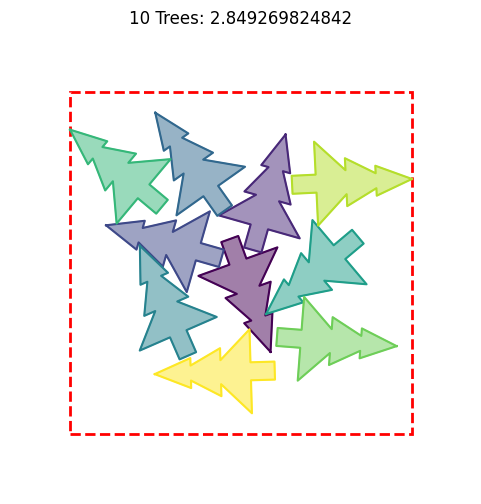

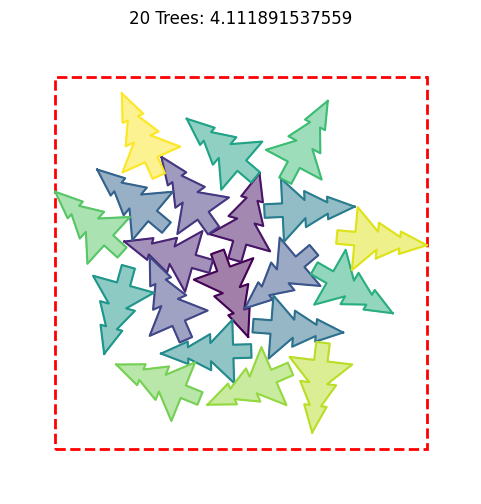

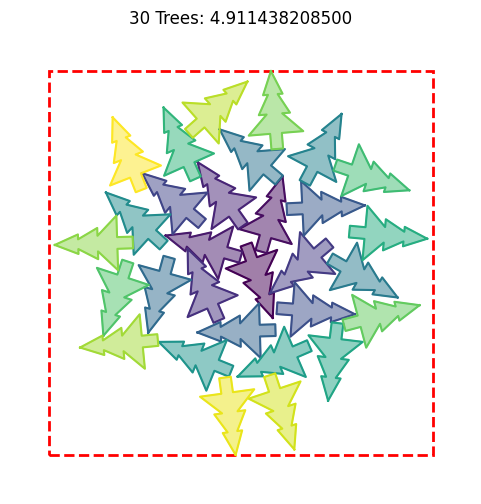

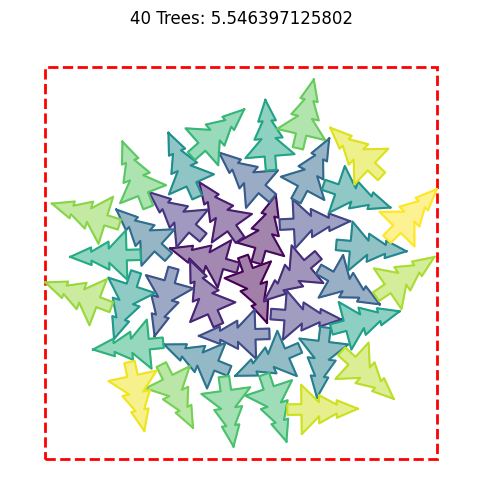

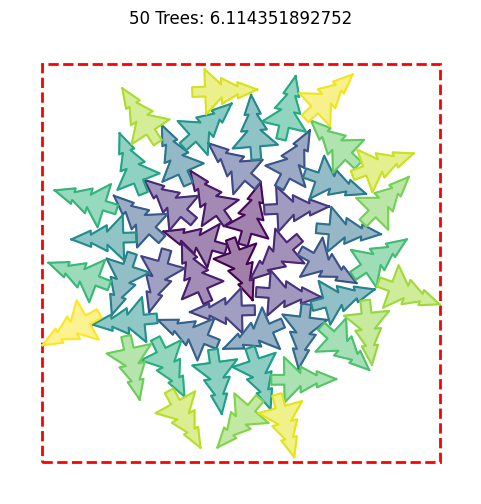

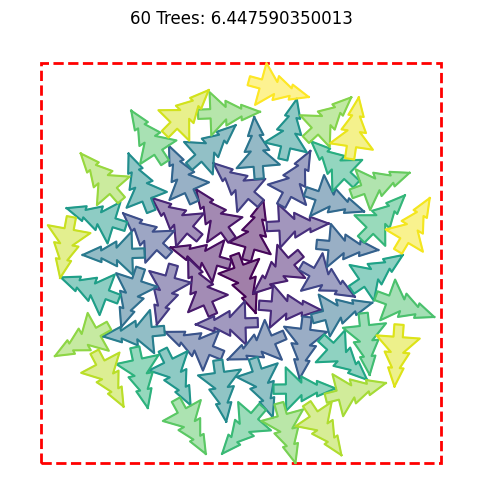

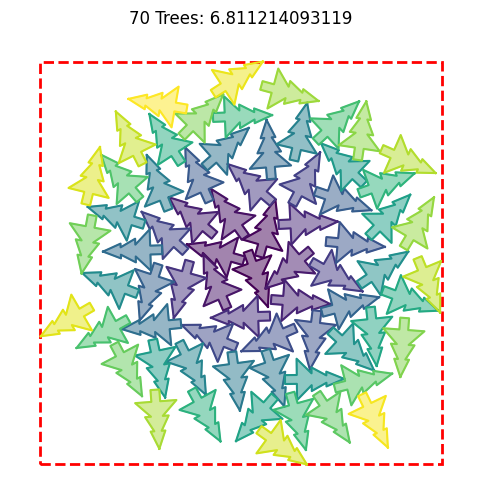

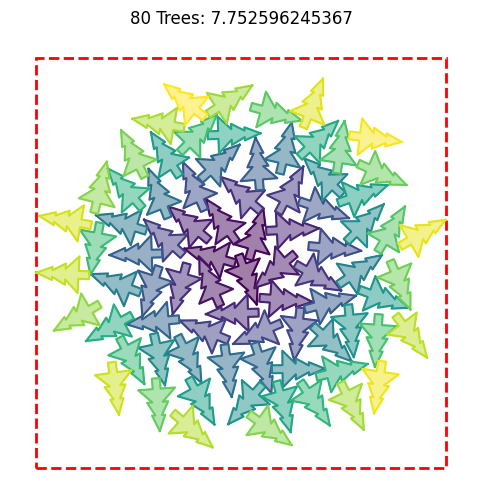

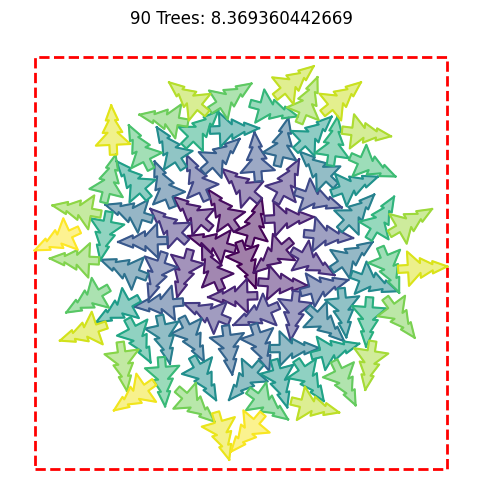

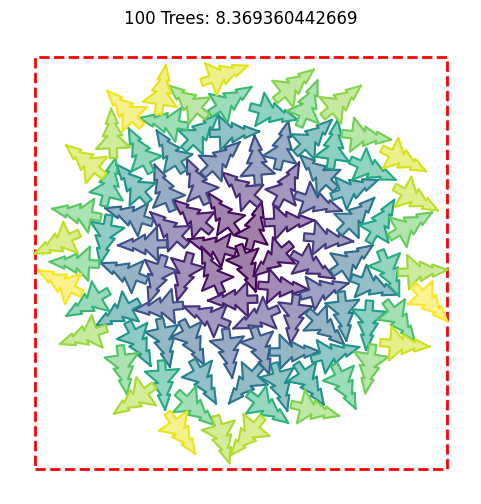

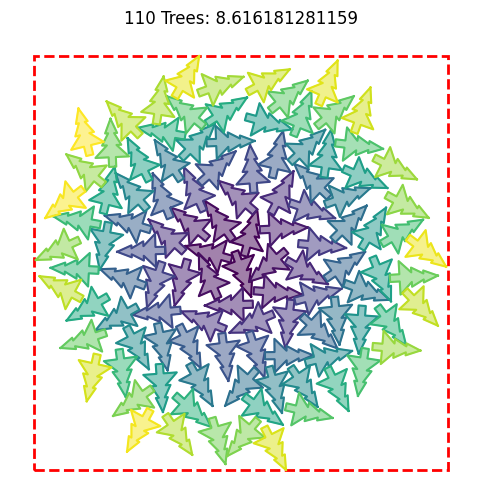

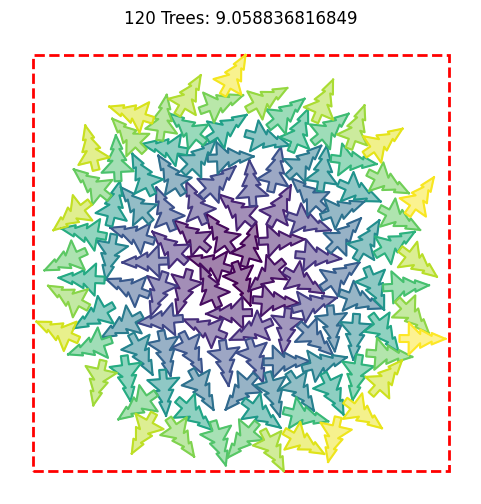

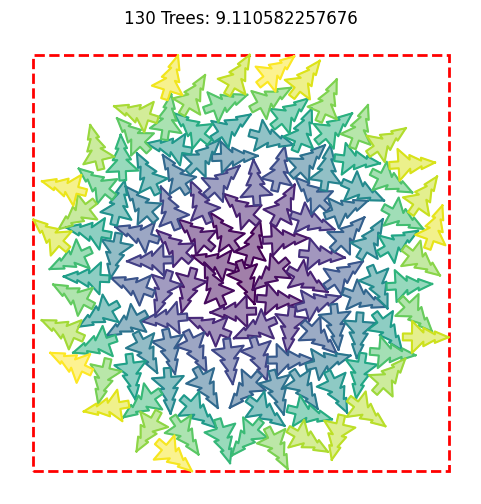

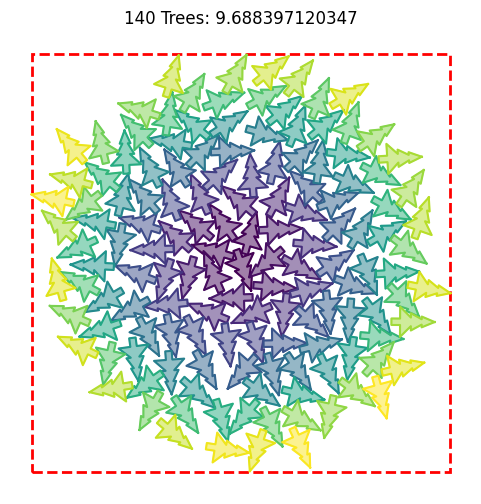

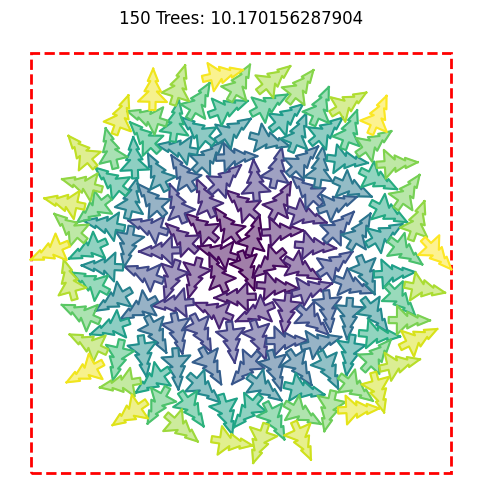

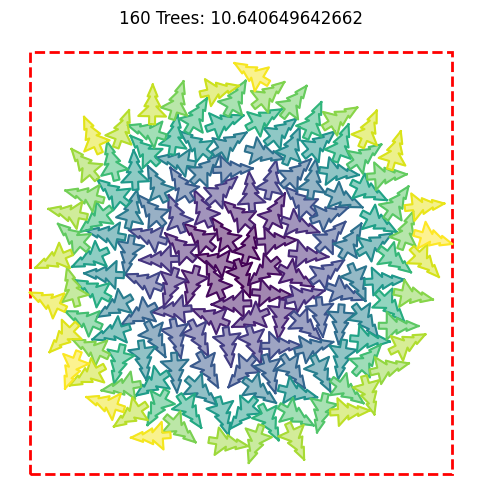

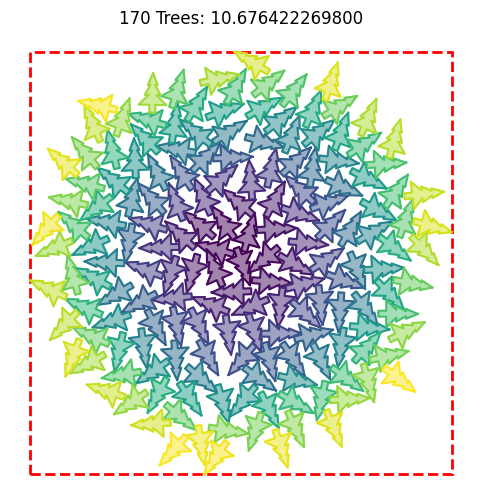

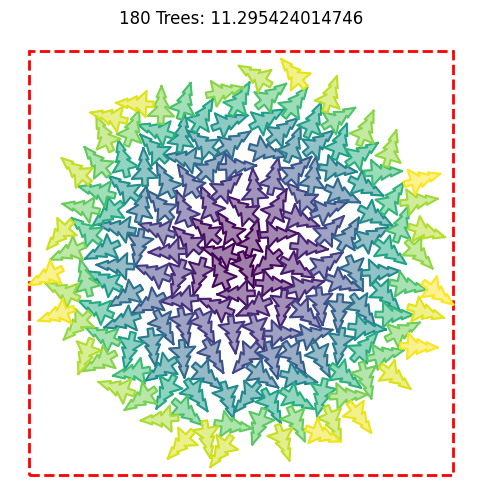

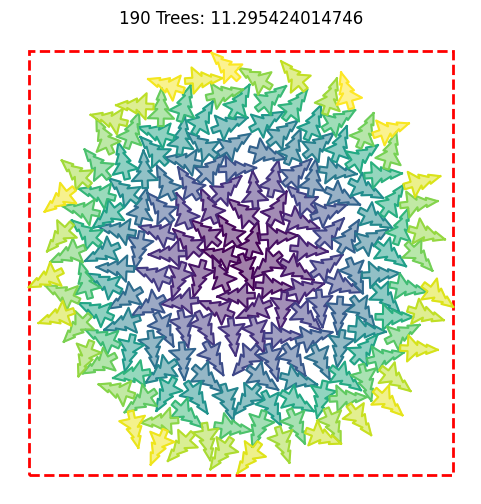

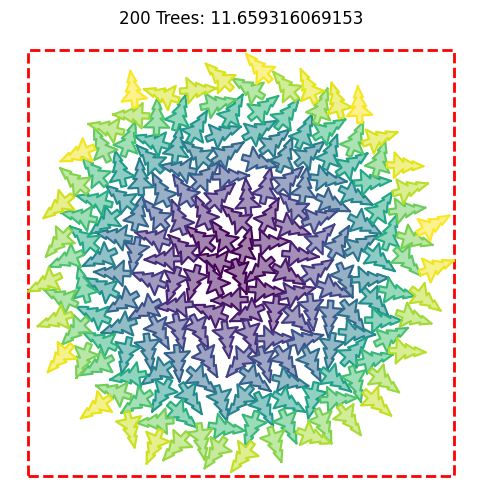

In [8]:
tree_data = []
current_placed_trees = []  # carried forward so each n uses previous placement

for n in range(200):
    current_placed_trees, side = initialize_trees(
        n + 1, existing_trees=current_placed_trees
    )

    # Plot every 10 trees as a sanity check / visualisation
    if (n + 1) % 10 == 0:
        plot_results(side, current_placed_trees, n + 1)

    # Append all tree positions for this n
    for tree in current_placed_trees:
        tree_data.append([tree.center_x, tree.center_y, tree.angle])

cols = ["x", "y", "deg"]
submission = (
    pd.DataFrame(index=index, columns=cols, data=tree_data)
    .rename_axis("id")
)

for col in cols:
    submission[col] = submission[col].astype(float)

# To ensure everything is kept as a string, prepend an 's'
for col in submission.columns:
    submission[col] = "s" + submission[col].astype("string")

submission.to_csv("/kaggle/working/" + "submission.csv")
